In [22]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import mysql.connector
import numpy as np
db = mysql.connector.connect(host = "localhost",
                             username ="root",
                             password = "eamon63@#189",
                             database = "ecommerce")

cur = db.cursor()
                             

# 1. List all unique cities where customers are located. 

In [43]:
query = """select distinct(customer_city)from customers"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data)
df.head()

,0
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas


# 2. Count the number of orders placed in 2017. 

In [6]:
query = """ select count(order_id)from orders where year(order_purchase_timestamp) = 2017"""

cur.execute(query)

data = cur.fetchall()

data

[(135303,)]

# 3. Find the total sales per category.

In [13]:
query = """ select products.product_category category,
round(sum(payments.payment_value),2) sales
from products join order_items
on products.product_id=order_items.product_id
join payments
on payments.order_id= order_items.order_id
group by category

"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data,columns = ["category","sales"])
df

,category,sales
0,perfumery,4560647.94
1,Furniture Decoration,12871587.53
2,telephony,4381938.46
3,bed table bath,15412983.04
4,automotive,7670648.98
...,...,...
69,cds music dvds,10794.87
70,La Cuisine,26221.77
71,Fashion Children's Clothing,7071.03
72,PC Gamer,19569.87


# 4. Calculate the percentage of orders that were paid in installments.

In [19]:
query = """ select (sum(case when payment_installments >= 1 then 1 else 0 end))/count(*) * 100 from payments

"""

cur.execute(query)

data = cur.fetchall()
data

[(Decimal('99.9981'),)]

# 5. Count the number of customers from each state. 


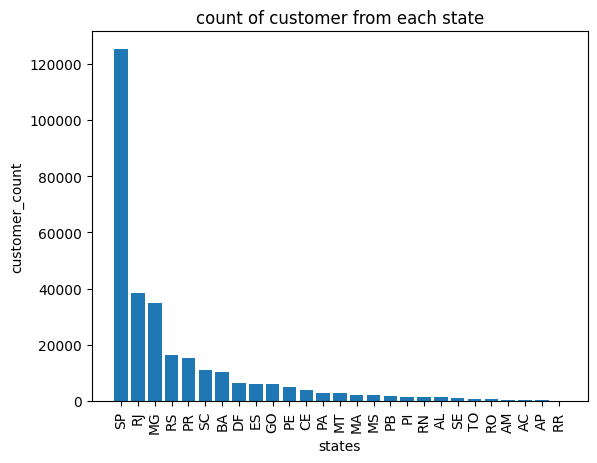

In [10]:
query = """ select customer_state, count(customer_id) 
            from customers 
            group by customer_state """

cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns=["state", "customer_count"])
df = df.sort_values(by="customer_count", ascending=False)

plt.bar(df["state"], df["customer_count"])  # ✅ fixed
plt.xticks(rotation=90)
plt.xlabel("states")
plt.ylabel("customer_count")
plt.title("count of customer from each state")
plt.show()  # ✅ fixed



# 1. Calculate the number of orders per month in 2018.

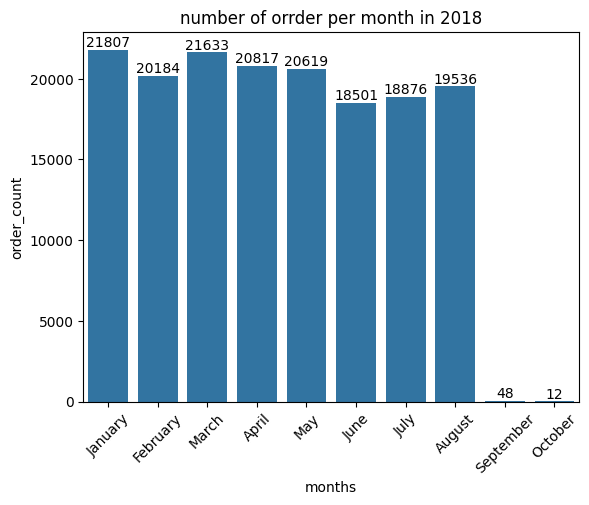

In [11]:
query = """ select monthname(order_purchase_timestamp)months,count(order_id)order_count
from orders where year (order_purchase_timestamp) = 2018
group by months

"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["months","order_count"])
o =  ["January","February","March","April","May","June","July","August","September","October"] 

ax = sns.barplot(x = df["months"], y = df["order_count"], data = df, order = o)
plt.xticks(rotation = 45)
plt.title("number of orrder per month in 2018")
ax.bar_label(ax.containers[0])

plt.show()


# 2. Find the average number of products per order, grouped by customer city.


In [12]:
query = """ WITH count_per_order AS (
    SELECT orders.order_id,
           orders.customer_id,
           COUNT(order_items.order_id) AS oc       -- ✅ alias added
    FROM orders
    JOIN order_items ON orders.order_id = order_items.order_id
    GROUP BY orders.order_id, orders.customer_id
)
SELECT customers.customer_city,
       AVG(count_per_order.oc) AS avg_items_per_order
FROM customers
JOIN count_per_order ON customers.customer_id = count_per_order.customer_id
GROUP BY customers.customer_city"""

cur.execute(query)

data = cur.fetchall()

data

[('treze tilias', Decimal('3.8182')),
 ('indaial', Decimal('3.3462')),
 ('sao jose dos campos', Decimal('3.4155')),
 ('sao paulo', Decimal('3.4686')),
 ('porto alegre', Decimal('3.5248')),
 ('santos', Decimal('3.4844')),
 ('sao francisco do sul', Decimal('3.7059')),
 ('sao vicente', Decimal('3.2727')),
 ('joinville', Decimal('3.3080')),
 ('sao vendelino', Decimal('3.0000')),
 ('belo horizonte', Decimal('3.4298')),
 ('bage', Decimal('3.1429')),
 ('gravatai', Decimal('3.1875')),
 ('sumare', Decimal('3.3978')),
 ('rio de janeiro', Decimal('3.4403')),
 ('navegantes', Decimal('3.4839')),
 ('chapada do norte', Decimal('3.0000')),
 ('frederico westphalen', Decimal('3.2143')),
 ('contagem', Decimal('3.4326')),
 ('curitiba', Decimal('3.4788')),
 ('guaranta', Decimal('3.0000')),
 ('miracema', Decimal('3.1579')),
 ('campo grande', Decimal('3.4286')),
 ('rodeio', Decimal('3.4286')),
 ('barueri', Decimal('3.3497')),
 ('urussanga', Decimal('3.0000')),
 ('osorio', Decimal('3.5143')),
 ('duque de caxi

# 3. Calculate the percentage of total revenue contributed by each product category.


In [28]:
query = """ SELECT 
    products.product_category category,
    round((SUM(payments.payment_value) / (SELECT 
            SUM(payment_value)
        FROM
            payments)) * 100,2) sales
FROM
    products
        JOIN
    order_items ON products.product_id = order_items.product_id
        JOIN
    payments ON payments.order_id = order_items.order_id
GROUP BY category
order by sales desc

;"""

cur.execute(query)

df = pd.DataFrame(data,columns = ["category","percentage "])
df

,category,percentage
0,bed table bath,32.09
1,HEALTH BEAUTY,31.06
2,computer accessories,29.71
3,Furniture Decoration,26.80
4,Watches present,26.78
...,...,...
69,PC Gamer,0.04
70,House Comfort 2,0.03
71,cds music dvds,0.02
72,Fashion Children's Clothing,0.01


# 4. Identify the correlation between product price and the number of times a product has been purchased.


In [5]:
query = """ SELECT 
    products.product_category,
    COUNT(order_items.product_id),        -- ✅ Fixed: order_item → order_items
    ROUND(AVG(order_items.price), 2)
FROM
    products
        JOIN
    order_items ON products.product_id = order_items.product_id
GROUP BY products.product_category;

;"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data,columns = ["category","order_count ","price"])
df

,category,order_count,price
0,HEALTH BEAUTY,29010,130.16
1,sport leisure,25923,114.34
2,Cool Stuff,11388,167.36
3,computer accessories,23481,116.51
4,Watches present,17973,201.14
...,...,...,...
69,Kitchen portable and food coach,45,264.57
70,House Comfort 2,90,25.34
71,CITTE AND UPHACK FURNITURE,114,114.95
72,insurance and services,6,141.64


# 5. Calculate the total revenue generated by each seller, and rank them by revenue.


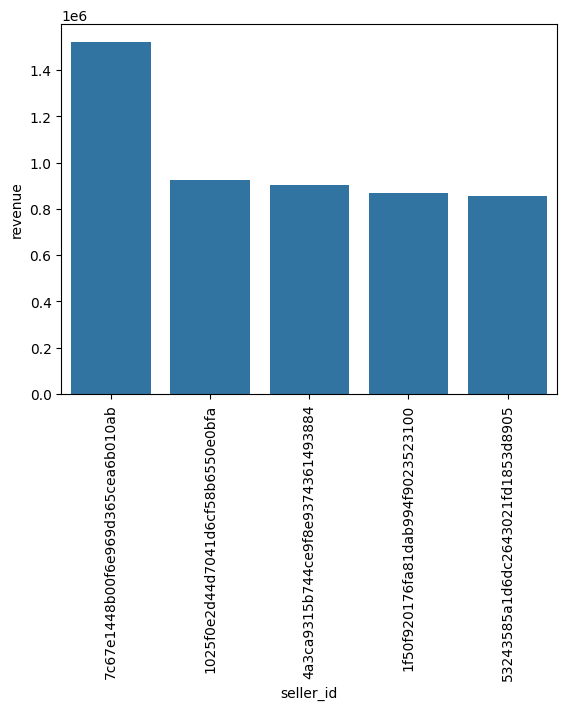

In [20]:
query = """
    SELECT *, DENSE_RANK() OVER (ORDER BY revenue DESC) AS rn
    FROM (
        SELECT 
            order_items.seller_id,
            SUM(payments.payment_value) AS revenue       
        FROM order_items
        JOIN payments ON order_items.order_id = payments.order_id
        GROUP BY order_items.seller_id
    ) AS a
"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["seller_id", "revenue","rank"])
df = df.head()
sns.barplot(x = "seller_id",y = "revenue", data = df )
plt.xticks(rotation = 90)
plt.show()


# 1. Calculate the moving average of order values for each customer over their order history.


In [21]:
 
query = """
    SELECT 
    customer_id,
    order_purchase_timestamp,
    payment_value,                                        
    AVG(payment_value) OVER (                            
        PARTITION BY customer_id 
        ORDER BY order_purchase_timestamp
        ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
    ) AS mov_avg
FROM (
    SELECT 
        orders.customer_id,
        orders.order_purchase_timestamp,
        payments.payment_value                            
    FROM payments
        JOIN orders ON payments.order_id = orders.order_id
) AS a;
"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data)
df

,0,1,2,3
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
1,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
2,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
3,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
4,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
...,...,...,...,...
934969,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,18.37,18.370001
934970,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,18.37,18.370001
934971,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,18.37,18.370001
934972,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,18.37,18.370001


# 2. Calculate the cumulative sales per month for each year.

In [23]:
query = """
select years,months,payment,sum(payment)
over (order by years,months) cumulative_sales from
(SELECT 
    YEAR(orders.order_purchase_timestamp) AS years,
    MONTH(orders.order_purchase_timestamp) AS months,
    ROUND(SUM(payments.payment_value), 2) as payment
FROM
    orders
        JOIN
    payments ON orders.order_id = payments.order_id
GROUP BY years , months
ORDER BY years , months)as a;
    
"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data)
df

,0,1,2,3
0,2016,9,2270.16,2.270160e+03
1,2016,10,531814.32,5.340845e+05
2,2016,12,176.58,5.342611e+05
3,2017,1,1246392.36,1.780653e+06
4,2017,2,2627172.09,4.407826e+06
5,2017,3,4048772.40,8.456598e+06
6,2017,4,3760092.27,1.221669e+07
7,2017,5,5336269.38,1.755296e+07
8,2017,6,4601487.42,2.215445e+07
9,2017,7,5331446.28,2.748589e+07


# 3. Calculate the year-over-year growth rate of total sales.


In [34]:
query = """
    WITH a AS (
        SELECT 
            YEAR(orders.order_purchase_timestamp) AS years,
            ROUND(SUM(payments.payment_value), 2) AS payment
        FROM orders
            JOIN payments ON orders.order_id = payments.order_id
        GROUP BY years 
        ORDER BY years
    ) 
    SELECT 
        years,
        ROUND(
            ((payment - LAG(payment, 1) OVER (ORDER BY years)) 
            / LAG(payment, 1) OVER (ORDER BY years)) * 100, 2
        ) AS `yoy % growth`                                    -- ✅ Fixed: moved * 100 inside, removed v
    FROM a
"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=["years", "yoy % growth"])
df

,years,yoy % growth
0,2016,NaN
1,2017,12112.7
2,2018,20.0


# 4. Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase.


In [38]:
query = """
    WITH first_purchase AS (
        SELECT 
            customer_id,
            MIN(order_purchase_timestamp) AS first_purchase_date
        FROM orders
        GROUP BY customer_id
    ),
    retained AS (
        SELECT 
            f.customer_id,
            f.first_purchase_date,
            MIN(o.order_purchase_timestamp) AS next_purchase_date
        FROM first_purchase f
        JOIN orders o 
            ON f.customer_id = o.customer_id
            AND o.order_purchase_timestamp > f.first_purchase_date
            AND o.order_purchase_timestamp <= DATE_ADD(f.first_purchase_date, INTERVAL 6 MONTH)
        GROUP BY f.customer_id, f.first_purchase_date
    )
    SELECT 
        COUNT(DISTINCT retained.customer_id)          AS retained_customers,   
        COUNT(DISTINCT first_purchase.customer_id)    AS total_customers,      
        ROUND(
            COUNT(DISTINCT retained.customer_id) * 100.0 / 
            COUNT(DISTINCT first_purchase.customer_id), 2
        )                                             AS retention_rate        
    FROM first_purchase
    LEFT JOIN retained ON first_purchase.customer_id = retained.customer_id
"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=["retained_customers", "total_customers", "retention_rate"])  
df

,retained_customers,total_customers,retention_rate
0,0,99441,0.00


# 5. Identify the top 3 customers who spent the most money in each year.

In [39]:
query = """
    WITH yearly_spending AS (
        SELECT 
            YEAR(orders.order_purchase_timestamp)  AS years,
            orders.customer_id,
            ROUND(SUM(payments.payment_value), 2)  AS total_spent
        FROM orders
        JOIN payments ON orders.order_id = payments.order_id
        GROUP BY years, orders.customer_id
    ),
    ranked AS (
        SELECT 
            years,
            customer_id,
            total_spent,
            DENSE_RANK() OVER (PARTITION BY years ORDER BY total_spent DESC) AS rn
        FROM yearly_spending
    )
    SELECT 
        years,
        customer_id,
        total_spent,
        rn AS `rank`
    FROM ranked
    WHERE rn <= 3
    ORDER BY years, rn
"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=["years", "customer_id", "total_spent", "rank"])
df

,years,customer_id,total_spent,rank
0,2016,a9dc96b027d1252bbac0a9b72d837fc6,12811.95,1
1,2016,1d34ed25963d5aae4cf3d7f3a4cda173,12606.66,2
2,2016,4a06381959b6670756de02e07b83815f,11050.02,3
3,2017,1617b1357756262bfa56ab541c47bc16,122976.72,1
4,2017,c6e2731c5b391845f6800c97401a43a9,62363.79,2
5,2017,3fd6777bbce08a352fddd04e4a7cc8f6,60539.94,3
6,2018,ec5b2ba62e574342386871631fafd3fc,65473.92,1
7,2018,f48d464a0baaea338cb25f816991ab1f,62299.89,2
8,2018,e0a2412720e9ea4f26c1ac985f6a7358,43284.96,3
